In [2]:
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore') 

In [3]:
DATASET="glass"

## 1

In [22]:
dataset = fetch_openml(DATASET)
X = dataset.data
y = dataset.target

### Текстовое описание датасета

In [23]:
dataset.DESCR

'**Author**:   \n**Source**: Unknown -   \n**Please cite**:   \n\n1. Title: Glass Identification Database\n \n 2. Sources:\n     (a) Creator: B. German\n         -- Central Research Establishment\n            Home Office Forensic Science Service\n            Aldermaston, Reading, Berkshire RG7 4PN\n     (b) Donor: Vina Spiehler, Ph.D., DABFT\n                Diagnostic Products Corporation\n                (213) 776-0180 (ext 3014)\n     (c) Date: September, 1987\n \n 3. Past Usage:\n     -- Rule Induction in Forensic Science\n        -- Ian W. Evett and Ernest J. Spiehler\n        -- Central Research Establishment\n           Home Office Forensic Science Service\n           Aldermaston, Reading, Berkshire RG7 4PN\n        -- Unknown technical note number (sorry, not listed here)\n        -- General Results: nearest neighbor held its own with respect to the\n              rule-based system\n \n 4. Relevant Information:n\n       Vina conducted a comparison test of her rule-based system,

In [24]:
X.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.51793,12.79,3.50,1.12,73.03,0.64,8.77,0.0,0.00
1,1.51643,12.16,3.52,1.35,72.89,0.57,8.53,0.0,0.00
2,1.51793,13.21,3.48,1.41,72.64,0.59,8.43,0.0,0.00
3,1.51299,14.40,1.74,1.54,74.55,0.00,7.59,0.0,0.00
4,1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.0,0.24


In [25]:
y.head()

0        build wind float
1        vehic wind float
2        build wind float
3               tableware
4    build wind non-float
Name: Type, dtype: category
Categories (6, object): ['build wind float', 'build wind non-float', 'vehic wind float', 'containers', 'headlamps', 'tableware']

По входным данным надо определенить типо стекла, который используется.
Нужно построить модель классификации для предсказывания типа стекла

## 2

Основная статистическая информация по данным:

In [26]:
X.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


In [27]:
y.describe()

count                      214
unique                       6
top       build wind non-float
freq                        76
Name: Type, dtype: object

(array([70.,  0.,  0.,  0., 17.,  0.,  0.,  0.,  9.,  0.,  0.,  0., 76.,
         0.,  0.,  0., 29.,  0.,  0., 13.]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 ,
        2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  ]),
 <BarContainer object of 20 artists>)

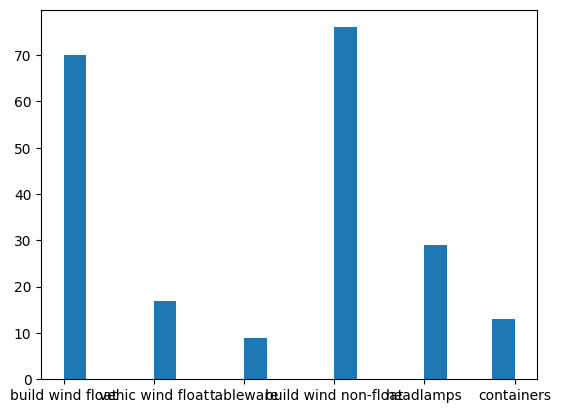

In [28]:
import matplotlib.pyplot as plt
plt.hist(y, bins=20)

Вывод по гистограмме: дисбаланс присутсвует, основная масса - окна build wind двух типов float и non-float, из более 30, остальные категории до 30 и могут отличаться в разы. 

## 3

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
dtypes: float64(9)
memory usage: 15.2 KB


In [12]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 214 entries, 0 to 213
Series name: Type
Non-Null Count  Dtype   
--------------  -----   
214 non-null    category
dtypes: category(1)
memory usage: 566.0 bytes


В данных нет пропусков, все признаки численные. Можно продолжать работу без рефактора данных.

## 4

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=42, shuffle=True, stratify=y)
X_train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
70,1.51829,14.46,2.24,1.62,72.38,0.00,9.26,0.00,0.00
119,1.51769,12.45,2.71,1.29,73.70,0.56,9.06,0.00,0.24
210,1.51592,12.86,3.52,2.12,72.66,0.69,7.97,0.00,0.00
90,1.51645,14.94,0.00,1.87,73.11,0.00,8.67,1.38,0.00
212,1.51689,12.67,2.88,1.71,73.21,0.73,8.54,0.00,0.00


In [30]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X=X_train, y=y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
model.score(X_train, y_train)

0.6391752577319587

In [32]:
model.score(X_test, y_test)

0.7

Подсчитывается Accuracy.Точность. Показывает долю правильных ответов

## 5

In [33]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import f1_score, recall_score, precision_score

f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')
print(f"""
f1 на трейне: {f1_train}\n
f1 на тесте: {f1_test}
""")



f1 на трейне: 0.611615120274914

f1 на тесте: 0.6228571428571429



In [35]:
recall_train = recall_score(y_train, y_train_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')
print(f"""
Реколл на трейне: {recall_train}\n
Реколл на тесте: {recall_test}
""")



Реколл на трейне: 0.6391752577319587

Реколл на тесте: 0.7



In [36]:
precision_train = precision_score(y_train, y_train_pred, average='weighted')
precision_test = precision_score(y_test, y_test_pred, average='weighted')
print(f"""
Пресижн на трейне: {precision_train}\n
Пресижн на тесте: {precision_test}
""")



Пресижн на трейне: 0.6043820631449497

Пресижн на тесте: 0.5625



## 6

In [44]:
from sklearn.metrics import roc_auc_score

y_score = model.predict_proba(X_test)  # shape: (n_samples, n_classes)

auc_macro_ovr = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",   # или "ovo"
    average="weighted",
    labels=model.classes_  # важно: порядок классов как в predict_proba
)

print(auc_macro_ovr)

0.8819902319902319


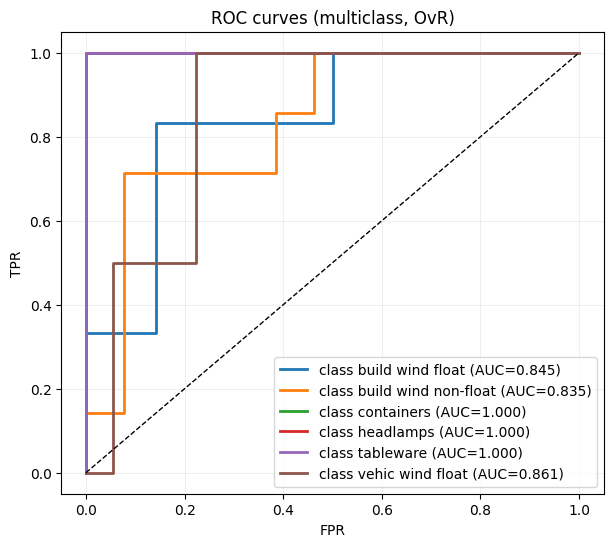

AUC macro   : 0.9235856735856736
AUC weighted: 0.8819902319902319


In [46]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

classes = model.classes_                 # порядок классов в predict_proba
y_score = model.predict_proba(X_test)    # (n_samples, n_classes)
y_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])  # class cls vs rest
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"class {cls} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curves (multiclass, OvR)")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

print("AUC macro   :", roc_auc_score(y_test, y_score, multi_class="ovr", average="macro", labels=classes))
print("AUC weighted:", roc_auc_score(y_test, y_score, multi_class="ovr", average="weighted", labels=classes))


Визуальное совпадение с теоретическим распределением в области малых значений. На больших значениях факт лучше чем прогноз

## 7

In [21]:
scaler = RobustScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
X_train_scaled.head()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX
0,1.085714,-0.528302,0.333333,-0.0625,1.0,0.842105
1,0.000000,-0.428816,0.333333,0.2500,0.0,-0.315789
2,-0.342857,0.857633,0.666667,1.7500,0.8,0.105263
3,4.514286,-0.428816,-0.333333,-0.1250,0.0,-0.315789
4,4.514286,-0.638079,-0.583333,-0.2500,0.0,-0.315789


In [22]:
model_sc = LinearRegression()
model_sc.fit(X=X_train_scaled, y=y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
model_sc.score(X_test_scaled, y_test)

0.8966683891893268

In [24]:
y_train_pred_sc = model_sc.predict(X_train_scaled)
y_test_pred_sc = model_sc.predict(X_test_scaled)

In [25]:
MAPE_train_sc = mean_absolute_percentage_error(y_train, y_train_pred_sc)
MAPE_test_sc = mean_absolute_percentage_error(y_test, y_test_pred_sc)
print(f"""
Средняя абсолютная ошибка в процентах на трейне: {MAPE_train_sc}\n
Средняя абсолютная ошибка в процентах на тесте: {MAPE_test_sc}
""")



Средняя абсолютная ошибка в процентах на трейне: 0.6662964698311131

Средняя абсолютная ошибка в процентах на тесте: 0.7317646104403371



In [26]:
RMSE_train_sc = root_mean_squared_error(y_train, y_train_pred_sc)
RMSE_test_sc = root_mean_squared_error(y_test, y_test_pred_sc)
print(f"""
Корень из среднеквадратичной ошибки на трейне: {RMSE_train_sc}\n
Корень из среднеквадратичной ошибки на тесте: {RMSE_test_sc}
""")



Корень из среднеквадратичной ошибки на трейне: 55.37746869559758

Корень из среднеквадратичной ошибки на тесте: 95.24956305996014



In [ ]:
MedAE_train_sc = median_absolute_error(y_train, y_train_pred_sc)
MedAE_test_sc = median_absolute_error(y_test, y_test_pred_sc)
print(f"""
Медианная абсолютная ошибка на трейне: {MedAE_train_sc}\n
Медианная абсолютная ошибка ошибки на тесте: {MedAE_test_sc}
""")


Медианная абсолютная ошибка на трейне: 23.38978171957968

Медианная абсолютная ошибка ошибки на тесте: 27.88602131248456



In [28]:
print(f"""
До нормализации:
MAPE train: {MAPE_train}
MAPE test: {MAPE_test}

После нормализации:
MAPE train: {MAPE_train_sc}
MAPE test: {MAPE_test_sc}
""")


До нормализации:
MAPE train: 0.6662964698311135
MAPE test: 0.7317646104403381

После нормализации:
MAPE train: 0.6662964698311131
MAPE test: 0.7317646104403371



In [29]:
print(f"""
До нормализации:
RMSE train: {RMSE_train}
RMSE test: {RMSE_test}

После нормализации:
RMSE train: {RMSE_train_sc}
RMSE test: {RMSE_test_sc}
""")


До нормализации:
RMSE train: 55.377468695597585
RMSE test: 95.24956305996008

После нормализации:
RMSE train: 55.37746869559758
RMSE test: 95.24956305996014



In [ ]:
print(f"""
До нормализации:
MedAE train: {MedAE_train}
MedAE test: {MedAE_test}

После нормализации:
MedAE train: {MedAE_train_sc}
MedAE test: {MedAE_test_sc}
""")


До нормализации:
MAE train: 23.389781719579766
MAE test: 27.886021312484633

После нормализации:
MAE train: 23.38978171957968
MAE test: 27.88602131248456



Нормализация практически не повлияла на работу модели, тк линейная регрессия не чувствительна к масштабу признаков.

## 8

In [31]:
model_dt = DecisionTreeRegressor(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

In [32]:
-scores, -np.mean(scores)

(array([96.41295729, 54.56698834, 38.24754894, 62.54170037, 32.73219121]),
 np.float64(56.900277231975224))

## 9

In [ ]:
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]  

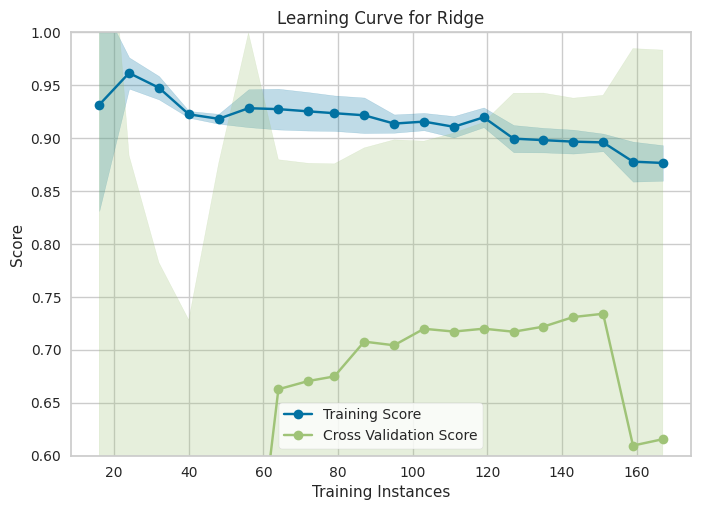

<Axes: title={'center': 'Learning Curve for Ridge'}, xlabel='Training Instances', ylabel='Score'>

In [46]:
visuilizer = LearningCurve(Ridge(), train_sizes=np.linspace(0.1, 1.0, 20))

visuilizer.fit(X,y)
plt.ylim(0.6,1)
visuilizer.show()

Вывод по графику обучения: Модель переобучилась, слишком высокий score (около 0.9-0.95) говорит о том что модель подстроилась под данные + cv score находится достаточно низко (gap ~ 0.2-0.3), т.е на val она работает плохо и хуже чем на трейне.

## 10

In [90]:
alphas = np.linspace(1, 1000, 100)

param_grid = {
    "alpha": alphas
}

grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    return_train_score=True
)

grid.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,{'alpha': array([ 1. ...000. ])}
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,np.float64(1000.0)


In [91]:
results = pd.DataFrame(grid.cv_results_)

results[['param_alpha', 'mean_train_score', 'mean_test_score', 'rank_test_score']]

,param_alpha,mean_train_score,mean_test_score,rank_test_score
0,1.000000,0.844348,0.715489,100
1,11.090909,0.844348,0.715568,99
2,21.181818,0.844348,0.715647,98
3,31.272727,0.844347,0.715725,97
4,41.363636,0.844347,0.715803,96
...,...,...,...,...
95,959.636364,0.844100,0.721211,5
96,969.727273,0.844096,0.721257,4
97,979.818182,0.844092,0.721303,3
98,989.909091,0.844088,0.721349,2


In [92]:
best_model = grid.best_estimator_
best_model

,alpha,np.float64(1000.0)
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [93]:
best_model.score(X_test, y_test)

0.8961987002690791